In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_curve, roc_auc_score, confusion_matrix)
import seaborn as sns

df = pd.read_csv("titanic.csv")
df["age"] = df["age"].fillna(df["age"].median())
df["sex"] = df["sex"].map({"male":1, "female":0})
df = df[["survived", "pclass", "sex", "age", "fare"]].dropna()

X = df.drop("survived", axis=1)
y = df["survived"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

param_grid = {
    "penalty": ["l1", "l2"],
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear"]
}

grid_log = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring="accuracy")
grid_log.fit(X_train, y_train)

print("best parameters:", grid_log.best_params_)
model1 = grid_log.best_estimator_

best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}


best penalty was L2. L1 is Lasso. L2 is ridge. Lasso completely eliminates certain features' weight to be 0, killing off some features. L2 is ridge. Ridge does not completely eliminate certain features, instead it weighs them all, non-zero.

best C parameter was 0.1. a low C like 0.1 means the model applies more penalty to large coefficients, keeping the model simpler. This makes sense for a small dataset like Titanic.

Accuracy: 0.7633587786259542
Precision: 0.7340425531914894
Recall: 0.6509433962264151
F1: 0.69
AUC: 0.8500241896468312


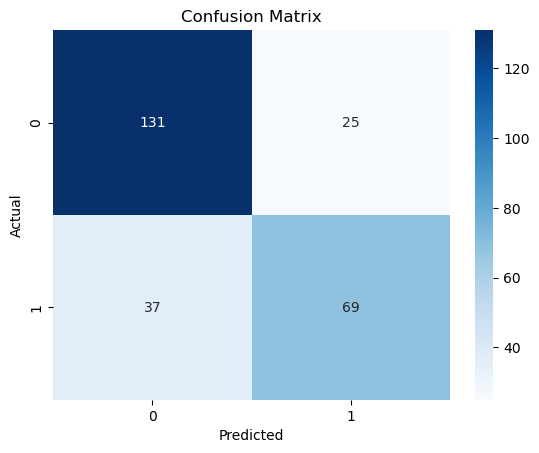

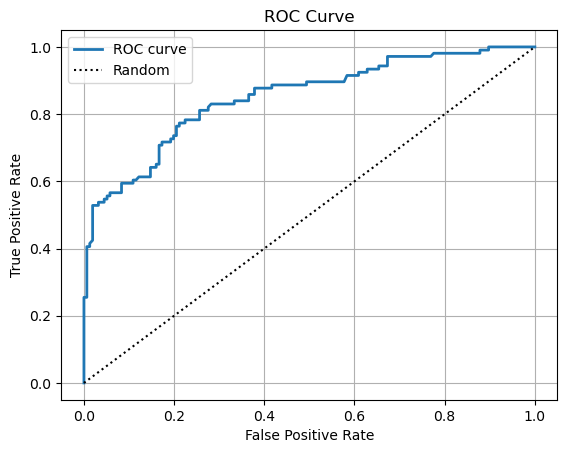

In [6]:
y_pred = model1.predict(X_test)
y_prob = model1.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0,1],[0,1], "k:", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

The model achieved 76% accuracy, meaning it correctly predicted survival or death about 3 out of 4 times. Precision was 73%, meaning when the model predicted someone survived, it was right 73% of the time. Recall was 65%, meaning it caught 65% of actual survivors. The AUC of 0.85 is quite good. The model correctly ranks a survivor above a non-survivor 85% of the time regardless of threshold.

For predicting death on the Titanic, Recall is the most appropriate metric. In a real rescue scenario, missing a survivor is far more costly than a false alarm. Our recall of 65% means we are still missing 35% of actual survivors, which leaves room for improvement.

It would not be appropriate to use linear regression here. Linear regression predicts continuous numbers which are meaningless when the only valid answers are 0 (died) or 1 (survived). Logistic regression is designed for binary classification because it squashes output to a probability between 0 and 1, then apply a threshold to make a yes/no decision.